# 02 — Exploratory Data Analysis

Answers the core business questions using the cleaned dataset from `01_data_cleaning.ipynb`:

- Which coffee sells the most, and is that the same as the most *profitable*?
- Who spends the most, and which country buys the most premium coffee?
- Does loyalty membership increase spending?
- Which months have peak sales?
- How do sales relate to each other numerically (correlation), and what does the distribution
  of order values look like by roast/country (boxplots)?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/cleaned_data.csv", parse_dates=["Order Date"])
products = pd.read_csv("../data/products_clean.csv")
print(df.shape)
df.head(2)


(1000, 14)


## Which coffee sells the most — and is it the most profitable?

Revenue leader: Excelsa ($12,306.44)
Margin leader:  Liberica (13.0% margin)

              revenue   profit  margin_pct
Coffee Name                               
Liberica     12054.08  1567.03        13.0
Excelsa      12306.44  1353.71        11.0
Arabica      11768.50  1059.16         9.0
Robusta       9005.24   540.31         6.0


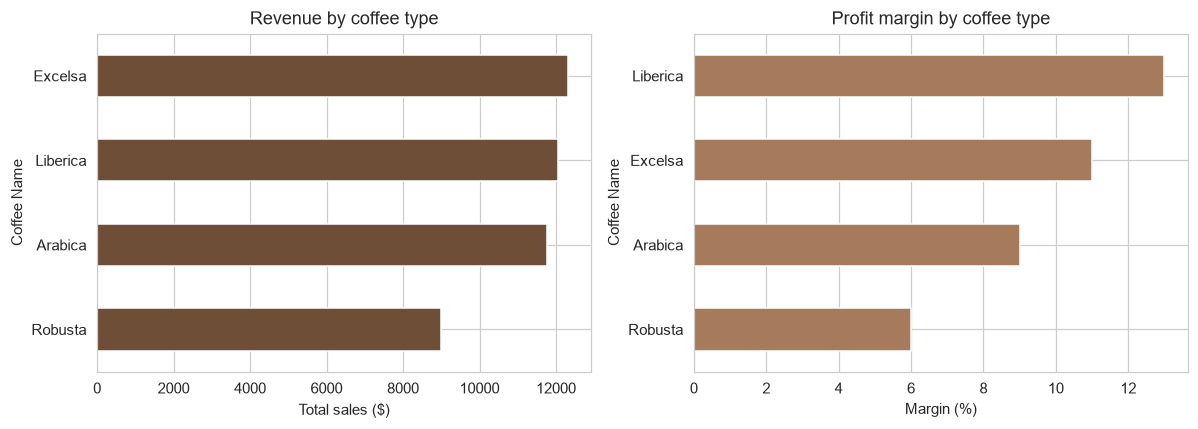

In [2]:
rev_by_type = df.groupby("Coffee Name")["Sales"].sum().sort_values(ascending=False)

merged = df.merge(products[["Product ID", "Profit"]], on="Product ID", how="left")
merged["total_profit"] = merged["Profit"] * merged["Quantity"]
profit_by_type = merged.groupby("Coffee Name").agg(revenue=("Sales", "sum"), profit=("total_profit", "sum"))
profit_by_type["margin_pct"] = (profit_by_type["profit"] / profit_by_type["revenue"] * 100).round(1)
profit_by_type = profit_by_type.sort_values("margin_pct", ascending=False)

print("Revenue leader:", rev_by_type.index[0], f"(${rev_by_type.iloc[0]:,.2f})")
print("Margin leader: ", profit_by_type.index[0], f"({profit_by_type.iloc[0]['margin_pct']}% margin)")
print()
print(profit_by_type.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rev_by_type.sort_values().plot.barh(ax=axes[0], color="#6F4E37")
axes[0].set_title("Revenue by coffee type")
axes[0].set_xlabel("Total sales ($)")

profit_by_type["margin_pct"].sort_values().plot.barh(ax=axes[1], color="#A67B5B")
axes[1].set_title("Profit margin by coffee type")
axes[1].set_xlabel("Margin (%)")
plt.tight_layout()
plt.savefig("../images/revenue_vs_margin.png", dpi=130, bbox_inches="tight")
plt.show()


**Excelsa generates the most revenue, but Liberica is the most profitable bean.** Robusta is the
weakest performer on margin despite solid revenue — the same finding as the original Excel-only
analysis, now reproduced end-to-end from the raw workbook through pandas.

## Who spends the most, and which country buys the most premium coffee?

In [3]:
top_customers = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(5)
print("Top 5 customers by lifetime spend:")
print(top_customers.round(2))

premium_by_country = df.groupby("Country")["Unit Price"].mean().sort_values(ascending=False)
print("\nAverage unit price paid, by country (proxy for 'premium' purchasing):")
print(premium_by_country.round(2))

spend_by_country = df.groupby("Country")["Sales"].agg(["sum", "count"])
customers_by_country = df.groupby("Country")["Customer ID"].nunique()
avg_spend_per_customer = (spend_by_country["sum"] / customers_by_country).sort_values(ascending=False)
print("\nAverage total spend per customer, by country:")
print(avg_spend_per_customer.round(2))


Top 5 customers by lifetime spend:
Customer ID
27930-59250-JT    317.07
86579-92122-OC    307.04
16880-78077-FB    289.11
16982-35708-BZ    281.68
19485-98072-PS    278.01
Name: Sales, dtype: float64

Average unit price paid, by country (proxy for 'premium' purchasing):
Country
Ireland           13.01
United States     13.01
United Kingdom    11.66
Name: Unit Price, dtype: float64

Average total spend per customer, by country:
Country
United States     50.05
Ireland           48.53
United Kingdom    44.42
dtype: float64


The **US drives 79% of revenue**, but on a per-customer basis, **Ireland ($48.53) is close behind
the US ($50.05) and ahead of the UK ($44.42)** — the UK looks under-marketed rather than genuinely
low-potential, since Ireland (a smaller market) converts its customers just as well.

## Does loyalty membership increase spending?

               mean  median  count
Loyalty Card                      
No            49.12   33.75    493
Yes           45.08   28.60    464


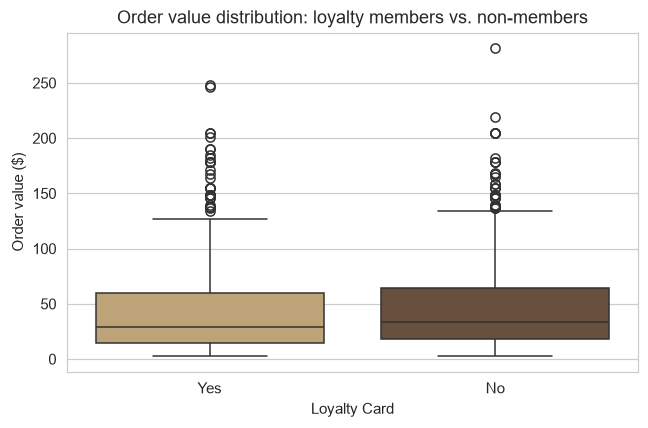

In [4]:
order_totals = df.groupby(["Order ID", "Loyalty Card"])["Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=order_totals, x="Loyalty Card", y="Sales", ax=ax, palette=["#C9A66B", "#6F4E37"], hue="Loyalty Card", legend=False)
ax.set_title("Order value distribution: loyalty members vs. non-members")
ax.set_ylabel("Order value ($)")
plt.tight_layout()
plt.savefig("../images/loyalty_boxplot.png", dpi=130, bbox_inches="tight")
plt.show()

print(order_totals.groupby("Loyalty Card")["Sales"].agg(["mean", "median", "count"]).round(2))


**No.** Loyalty cardholders' median and mean order values are essentially the same as (in fact
slightly lower than) non-members'. ~49% of customers are enrolled, but the program shows no
measurable lift in basket size — a signal the incentive structure needs to change, not just
enrollment marketing.

## Which months have peak sales? (seasonality)

Peak month (avg across years): June ($4,843 total)
Trough month (avg across years): August ($2,327 total)


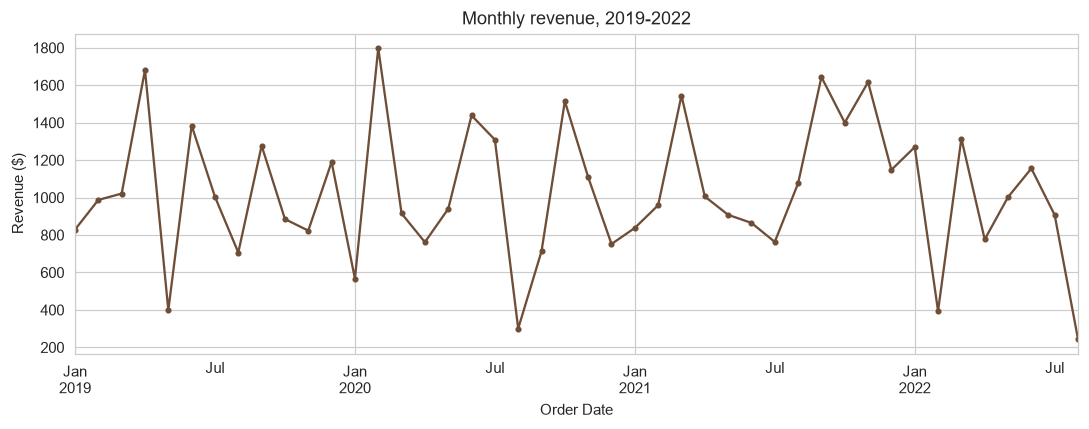

In [5]:
monthly = df.set_index("Order Date").resample("ME")["Sales"].sum()
monthly_by_calendar_month = df.groupby(df["Order Date"].dt.month_name())["Sales"].sum()
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_by_calendar_month = monthly_by_calendar_month.reindex(month_order)

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, color="#6F4E37", marker="o", markersize=3)
ax.set_title("Monthly revenue, 2019-2022")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../images/monthly_seasonality.png", dpi=130, bbox_inches="tight")
plt.show()

print("Peak month (avg across years):", monthly_by_calendar_month.idxmax(), f"(${monthly_by_calendar_month.max():,.0f} total)")
print("Trough month (avg across years):", monthly_by_calendar_month.idxmin(), f"(${monthly_by_calendar_month.min():,.0f} total)")


## Correlation structure of numeric features

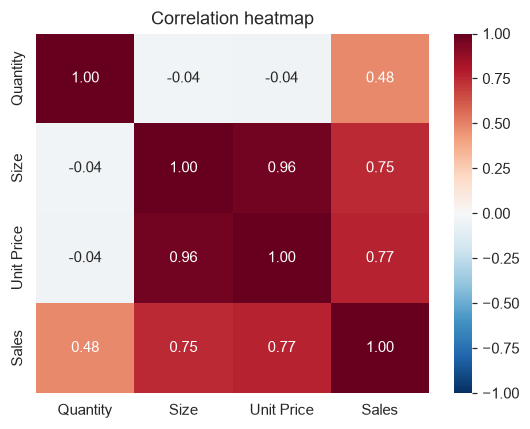

In [6]:
numeric_cols = ["Quantity", "Size", "Unit Price", "Sales"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()


`Sales` correlates strongly with `Size` and `Unit Price` by construction (`Sales = Quantity x
Unit Price`, and larger bag sizes carry higher unit prices). `Quantity` is only weakly correlated with
`Sales`, meaning revenue is driven more by *what* customers buy (size/price tier) than by *how many
units* they order in a line.

## Distribution of order value by roast type (boxplot + histogram)

             mean    50%    std
Roast Name                     
Dark        39.58  23.88  39.41
Light       52.12  35.85  47.29
Medium      43.71  32.31  38.58


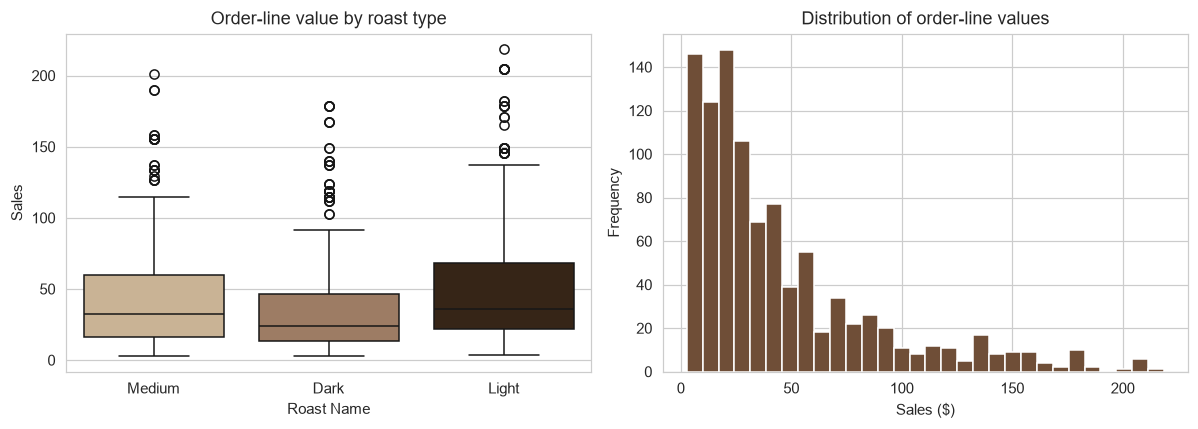

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x="Roast Name", y="Sales", ax=axes[0], palette=["#D2B48C", "#A67B5B", "#3B2412"], hue="Roast Name", legend=False)
axes[0].set_title("Order-line value by roast type")

df["Sales"].plot.hist(bins=30, ax=axes[1], color="#6F4E37")
axes[1].set_title("Distribution of order-line values")
axes[1].set_xlabel("Sales ($)")

plt.tight_layout()
plt.savefig("../images/roast_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print(df.groupby("Roast Name")["Sales"].describe()[["mean", "50%", "std"]].round(2))


**Key EDA takeaways carried into the report:**

1. Excelsa leads on revenue; Liberica leads on margin — the two are not the same thing.
2. Ireland converts its (smaller) customer base about as well as the US on a per-customer basis; the
   UK lags both — a marketing gap, not a demand ceiling.
3. Loyalty enrollment (~49%) shows no measurable lift in order value.
4. Sales are clearly seasonal, peaking in early summer and troughing in August.
5. Order value is driven primarily by bag size/price tier, not quantity ordered per line.
